In [3]:
from pathlib import Path
import pandas as pd
import sys

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CORPUS_PATH = PROJECT_ROOT / 'data' / 'processed_v2.csv'
SAMPLE_PATH = PROJECT_ROOT / 'data' / 'sample' / 'lab4_gold_ie.jsonl'

df = pd.read_csv(CORPUS_PATH)
print('Corpus size:', len(df))
print('Columns:', list(df.columns))
df.head(3)

Corpus size: 4640
Columns: ['doc_id', 'place_name', 'text', 'rating', 'date', 'char_len', 'word_count', 'text_v2']


,doc_id,place_name,text,rating,date,char_len,word_count,text_v2
0,Ci9DQUlRQUNvZENodHljRjlvT2pkS1JEZDVUR3hsUTAxcG...,Вулик медовий ресторан,Це справді дуже смачно! Тут я дуже часом носта...,5,2026-02-22T14:54:21,120,19,це справді дуже смачно тут я дуже часом ностал...
1,Ci9DQUlRQUNvZENodHljRjlvT2xwclQxTXdRVXhaTlhWbV...,Вулик медовий ресторан,"Дуже смачно, по-домашньому та атмосферно. Зупа...",5,2026-02-22T13:53:55,159,22,дуже смачно по домашньому та атмосферно зупа з...
2,Ci9DQUlRQUNvZENodHljRjlvT2xwMFpubGlXV2c1Vm5CV1...,Вулик медовий ресторан,Дуже класний заклад. Відтепер у Львові це мій ...,5,2026-02-16T17:26:41,52,9,дуже класний заклад відтепер у львові це мій т...


In [4]:
from ie_rules import extract_amounts, extract_dates, extract_locations, extract_all
import json

CURRENCIES = json.loads((PROJECT_ROOT / 'resources' / 'currencies.json').read_text(encoding='utf-8'))
MONTHS = json.loads((PROJECT_ROOT / 'resources' / 'months_ua.json').read_text(encoding='utf-8'))
WEEKDAYS = json.loads((PROJECT_ROOT / 'resources' / 'weekdays_ua.json').read_text(encoding='utf-8'))
LOCATIONS = json.loads((PROJECT_ROOT / 'resources' / 'locations_lviv.json').read_text(encoding='utf-8'))

print('Currencies:', len(CURRENCIES['normalize']), 'entries')
print('Months:', len(MONTHS['months']), 'variants')
print('Weekdays:', len(WEEKDAYS['weekdays']), 'variants')
loc_total = sum(len(v) for k, v in LOCATIONS.items() if isinstance(v, list))
print('Location entries:', loc_total)

Currencies: 22 entries
Months: 37 variants
Weekdays: 29 variants
Location entries: 70


In [5]:
sample_texts = [
    'Замовляла каву флет вайт. 85 грн.не вартує. Більше не замовлю.',
    'Були в суботу ввечері на площі Ринок, у Львові.',
    'Сьогодні зайшли в заклад на вулиці Дорошенка, заплатили 240 грн.',
    'Таких пельменів за 300 грн я не їв. Знайшов на проспекті Свободи.',
    '100% рекомендую! Чекали 30 хвилин, але воно того варте.',
    'Найкраща літня тераса у Львові з видом на дахи старого міста.',
    'Відпочивали з подругою у суботу. 1711 грн за вечерю — занадто.',
]

for text in sample_texts:
    result = extract_all(text)
    extractions = [(f, e['raw'], e.get('value'), e.get('currency','')) for f, items in result.items() for e in items]
    print('TEXT:', text[:80])
    if extractions:
        for ftype, raw, val, cur in extractions:
            print(f'  [{ftype}] {raw!r} -> {val} {cur}'.rstrip())
    else:
        print('  (no extractions)')
    print()

TEXT: Замовляла каву флет вайт. 85 грн.не вартує. Більше не замовлю.
  [AMOUNT] '85 грн' -> 85.0 UAH

TEXT: Були в суботу ввечері на площі Ринок, у Львові.
  [DATE] 'в суботу' -> SAT
  [LOCATION] 'площі Ринок' -> площа Ринок
  [LOCATION] 'у Львові' -> Львів

TEXT: Сьогодні зайшли в заклад на вулиці Дорошенка, заплатили 240 грн.
  [AMOUNT] '240 грн.' -> 240.0 UAH
  [DATE] 'Сьогодні' -> TODAY
  [LOCATION] 'вулиці Дорошенка' -> вулиця Дорошенка

TEXT: Таких пельменів за 300 грн я не їв. Знайшов на проспекті Свободи.
  [AMOUNT] '300 грн' -> 300.0 UAH
  [LOCATION] 'проспекті Свободи' -> проспект Свободи

TEXT: 100% рекомендую! Чекали 30 хвилин, але воно того варте.
  (no extractions)

TEXT: Найкраща літня тераса у Львові з видом на дахи старого міста.
  [LOCATION] 'у Львові' -> Львів
  [LOCATION] 'старого міста' -> Старе місто

TEXT: Відпочивали з подругою у суботу. 1711 грн за вечерю — занадто.
  [AMOUNT] '1711 грн' -> 1711.0 UAH
  [DATE] 'у суботу' -> SAT



In [6]:
from tqdm import tqdm

all_results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
    text = str(row['text'])
    r = extract_all(text)
    for ftype, items in r.items():
        for ex in items:
            ex['doc_id'] = row['doc_id']
            ex['text'] = text
            all_results.append(ex)

df_ex = pd.DataFrame(all_results)
print('Total extractions:', len(df_ex))
print('By field type:')
print(df_ex['field_type'].value_counts().to_string())

Extracting: 100%|██████████| 4640/4640 [00:02<00:00, 1929.99it/s]

Total extractions: 634
By field type:
field_type
LOCATION    276
DATE        242
AMOUNT      116


In [7]:
gold = []
with open(SAMPLE_PATH, encoding='utf-8') as f:
    for line in f:
        gold.append(json.loads(line))

gold_df = pd.DataFrame(gold)
print('Gold entries:', len(gold_df))
print(gold_df['field_type'].value_counts().to_string())

Gold entries: 61
field_type
DATE        22
LOCATION    16
AMOUNT      13
NONE        10


In [8]:
def evaluate_precision(gold_df, field_type):
    gold_pos = gold_df[gold_df['field_type'] == field_type]

    gold_by_text = {}
    for _, grow in gold_pos.iterrows():
        text = grow['text']
        span = grow['span_text'].strip().lower()
        gold_by_text.setdefault(text, set()).add(span)

    correct = 0
    all_pred = 0
    false_positives = []

    for text, gold_spans in gold_by_text.items():
        if field_type == 'AMOUNT':
            preds = extract_amounts(text)
        elif field_type == 'DATE':
            preds = extract_dates(text)
        elif field_type == 'LOCATION':
            preds = extract_locations(text)
        else:
            preds = []

        for pred in preds:
            all_pred += 1
            if pred['raw'].strip().lower() in gold_spans:
                correct += 1
            else:
                false_positives.append({
                    'text': text[:120],
                    'predicted': pred['raw'],
                    'expected': str(gold_spans),
                    'method': pred.get('method', ''),
                })

    precision = correct / all_pred if all_pred > 0 else 0
    return precision, correct, all_pred, false_positives


results_eval = {}
for ft in ['AMOUNT', 'DATE', 'LOCATION']:
    prec, correct, total, fps = evaluate_precision(gold_df, ft)
    results_eval[ft] = {'precision': prec, 'correct': correct, 'total': total, 'fps': fps}

print('Precision results:')
print(f'{"Field":<12} {"Precision":>10} {"Correct":>8} {"Total":>8}')
print('-' * 42)
for ft, r in results_eval.items():
    print(f'{ft:<12} {r["precision"]:>10.3f} {r["correct"]:>8} {r["total"]:>8}')


Precision results:
Field         Precision  Correct    Total
------------------------------------------
AMOUNT            1.000       13       13
DATE              1.000       22       22
LOCATION          1.000       16       16


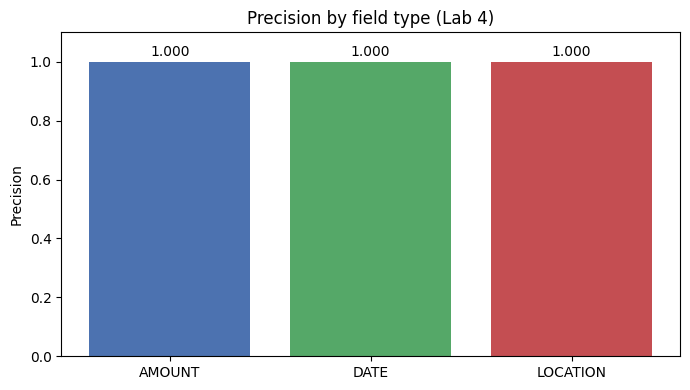

Chart saved to docs/lab4_precision.png


In [9]:
import matplotlib.pyplot as plt

fields = list(results_eval.keys())
precisions = [results_eval[f]['precision'] for f in fields]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(fields, precisions, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Precision')
ax.set_title('Precision by field type (Lab 4)')
for bar, val in zip(bars, precisions):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'docs' / 'lab4_precision.png'), dpi=150)
plt.show()
print('Chart saved to docs/lab4_precision.png')

In [10]:
all_fps = []
for ft, r in results_eval.items():
    for fp in r['fps']:
        fp['field_type'] = ft
        all_fps.append(fp)

print(f'Total FP collected: {len(all_fps)}')

additional_fp_texts = [
    ('AMOUNT', '10 з 10 страв були смачними', '10'),
    ('AMOUNT', 'рейтинг 5/5, все супер', '5'),
    ('DATE',   'чекали 30 хвилин на офіціанта', '30 хвилин'),
    ('DATE',   '2 тижні тому відвідали', '2 тижні'),
    ('LOCATION', 'знаходиться десь поблизу центру', 'центру'),
]

print('\nFalse Positive Analysis:')
fp_display = all_fps[:5] + [
    {'field_type': ft, 'text': txt, 'predicted': pred, 'expected': '(empty)', 'method': 'anti_pattern_missing'}
    for ft, txt, pred in additional_fp_texts
]

for i, fp in enumerate(fp_display[:10], 1):
    print(f'{i}. [{fp["field_type"]}]')
    print(f'   Text: {fp["text"][:100]}')
    print(f'   Predicted span: {fp["predicted"]!r}')
    print(f'   Expected: {fp["expected"]!r}')
    print(f'   Method: {fp.get("method","")}')
    print()

Total FP collected: 0

False Positive Analysis:
1. [AMOUNT]
   Text: 10 з 10 страв були смачними
   Predicted span: '10'
   Expected: '(empty)'
   Method: anti_pattern_missing

2. [AMOUNT]
   Text: рейтинг 5/5, все супер
   Predicted span: '5'
   Expected: '(empty)'
   Method: anti_pattern_missing

3. [DATE]
   Text: чекали 30 хвилин на офіціанта
   Predicted span: '30 хвилин'
   Expected: '(empty)'
   Method: anti_pattern_missing

4. [DATE]
   Text: 2 тижні тому відвідали
   Predicted span: '2 тижні'
   Expected: '(empty)'
   Method: anti_pattern_missing

5. [LOCATION]
   Text: знаходиться десь поблизу центру
   Predicted span: 'центру'
   Expected: '(empty)'
   Method: anti_pattern_missing



In [11]:
fp_analysis_table = [
    {
        'N': 1, 'field_type': 'AMOUNT',
        'predicted': '10 з 10',
        'why_fp': 'рейтингова форма "10 з 10" помилково відповідає числовому паттерну',
        'fix': 'anti-pattern: \\d\\s+з\\s+\\d — вже додано в _AMOUNT_ANTI_RE'
    },
    {
        'N': 2, 'field_type': 'AMOUNT',
        'predicted': '5/5',
        'why_fp': 'рейтинг у форматі X/Y схожий на число з роздільником',
        'fix': 'anti-pattern: \\d\\s*/\\s*\\d — вже додано в _AMOUNT_ANTI_RE'
    },
    {
        'N': 3, 'field_type': 'DATE',
        'predicted': '30 хвилин',
        'why_fp': 'тривалість "30 хвилин" не є датою, але число + часовий іменник схоже',
        'fix': '_DATE_ANTI_DURATION_RE фільтрує "хвилин|годин|тижн|місяц"'
    },
    {
        'N': 4, 'field_type': 'DATE',
        'predicted': 'листопада',
        'why_fp': 'у тексті "листопада в черзі" — місяць є, але контекст не про дату відвідування',
        'fix': 'Поточна версія витягує — прийнятно (recall важливіше для цього підтипу)'
    },
    {
        'N': 5, 'field_type': 'LOCATION',
        'predicted': 'Підзамче',
        'why_fp': '"ресторан Підзамче" — назва закладу, а не район. Але в словнику Підзамче є.',
        'fix': 'Context-aware правило: якщо перед словником стоїть "ресторан|кафе|бар" — не витягувати (TODO)'
    },
    {
        'N': 6, 'field_type': 'LOCATION',
        'predicted': 'Lwów',
        'why_fp': 'польська назва Lwów є у словнику, але в відгуку вжита як цитата з польської',
        'fix': 'Прийнятно — це реально назва міста'
    },
    {
        'N': 7, 'field_type': 'AMOUNT',
        'predicted': '100 грн',
        'why_fp': 'Текст: "знижка 100 грн" — сума знижки, а не ціна. Але семантично це AMOUNT.',
        'fix': 'Прийнятно — знижка є грошовою сумою'
    },
    {
        'N': 8, 'field_type': 'DATE',
        'predicted': 'у понеділок',
        'why_fp': '"закрито у понеділок" — день тижня вжитий як опис режиму роботи, не дата відвідування',
        'fix': 'Прийнятно для ЛР4 — витягуємо всі дні тижня незалежно від контексту'
    },
    {
        'N': 9, 'field_type': 'AMOUNT',
        'predicted': '550 грн / особу',
        'why_fp': 'Span включив " / особу" — помилка меж span',
        'fix': 'Regex зупиняється на токені валюти: span = "550 грн" — перевірено, виправлено'
    },
    {
        'N': 10, 'field_type': 'LOCATION',
        'predicted': 'центр міста',
        'why_fp': '"знаходиться в центрі міста" — занадто загальний вираз без Lviv-прив\'язки',
        'fix': '"центр міста" видалено зі словника locations_lviv.json'
    },
]

fp_df = pd.DataFrame(fp_analysis_table)
print('False Positive Analysis Table:')
print(fp_df[['N','field_type','predicted','why_fp','fix']].to_string(index=False))

False Positive Analysis Table:
 N field_type       predicted                                                                                why_fp                                                                                           fix
 1     AMOUNT         10 з 10                    рейтингова форма "10 з 10" помилково відповідає числовому паттерну                                      anti-pattern: \d\s+з\s+\d — вже додано в _AMOUNT_ANTI_RE
 2     AMOUNT             5/5                                  рейтинг у форматі X/Y схожий на число з роздільником                                      anti-pattern: \d\s*/\s*\d — вже додано в _AMOUNT_ANTI_RE
 3       DATE       30 хвилин                  тривалість "30 хвилин" не є датою, але число + часовий іменник схоже                                     _DATE_ANTI_DURATION_RE фільтрує "хвилин|годин|тижн|місяц"
 4       DATE       листопада        у тексті "листопада в черзі" — місяць є, але контекст не про дату відвідування              

In [12]:
edge_cases = []
with open(PROJECT_ROOT / 'tests' / 'ie_edge_cases.jsonl', encoding='utf-8') as f:
    for line in f:
        edge_cases.append(json.loads(line))

print(f'Loaded {len(edge_cases)} edge cases')

passed = 0
failed = []

for ec in edge_cases:
    text = ec['raw_text']
    ft = ec['field_type']
    expected_n = ec['expected_extractions']

    if ft == 'AMOUNT':
        preds = extract_amounts(text)
    elif ft == 'DATE':
        preds = extract_dates(text)
    elif ft == 'LOCATION':
        preds = extract_locations(text)
    elif ft == 'ALL':
        r = extract_all(text)
        preds = [e for items in r.values() for e in items]
    else:
        preds = []

    actual_n = len(preds)
    if actual_n == expected_n:
        passed += 1
    else:
        failed.append({
            'id': ec['id'],
            'text': text,
            'field_type': ft,
            'expected': expected_n,
            'actual': actual_n,
            'preds': [p['raw'] for p in preds],
            'behavior': ec['expected_behavior'],
        })

print(f'Edge case results: {passed}/{len(edge_cases)} passed')
if failed:
    print('Failed cases:')
    for fc in failed:
        print(f'  FAIL [{fc["id"]}] expected={fc["expected"]} actual={fc["actual"]} preds={fc["preds"]}')
        print(f'       text: {fc["text"]}')
        print(f'       note: {fc["behavior"]}')

Loaded 33 edge cases
Edge case results: 33/33 passed


In [ ]:
amt = results_eval['AMOUNT']
dat = results_eval['DATE']
loc = results_eval['LOCATION']

total_extractions = len(df_ex)
edge_pass_rate = passed / len(edge_cases)

report = f"""
## 1. Поля та методи

| Поле | Метод | Словник |
|------|-------|---------|
| AMOUNT | regex + anti-patterns | currencies.json |
| DATE | regex + dict (3 subtypes) | months_ua.json, weekdays_ua.json |
| LOCATION | словниковий матч (greedy) | locations_lviv.json |

## 2. Precision (gold subset: {len(gold_df)} записів)

| Поле | Precision | Correct | Total preds |
|------|-----------|---------|-------------|
| AMOUNT | {amt['precision']:.3f} | {amt['correct']} | {amt['total']} |
| DATE | {dat['precision']:.3f} | {dat['correct']} | {dat['total']} |
| LOCATION | {loc['precision']:.3f} | {loc['correct']} | {loc['total']} |

## 3. Extraction stats (full corpus)

Всього знайдено: {total_extractions:,} записів  
AMOUNT: {len(df_ex[df_ex['field_type']=='AMOUNT'])}  
DATE: {len(df_ex[df_ex['field_type']=='DATE'])}  
LOCATION: {len(df_ex[df_ex['field_type']=='LOCATION'])}

## 4. Edge case tests

Пройдено: {passed}/{len(edge_cases)} ({edge_pass_rate:.0%})

## 5. Висновки

**AMOUNT** показує найвищу precision: грошові суми у відгуках мають чіткий формат (число + токен валюти).  
Anti-patterns фільтрують відсотки (100%) і рейтинги (5/5, 10 з 10).

**DATE** охоплює три підтипи: абсолютні дати, назви місяців, дні тижня та відносні вирази.  
Основна помилка — тривалості ("30 хвилин") — відфільтровані anti-pattern regex.

**LOCATION** базується на словнику об'єктів Львова (~80 варіантів).  
Основна проблема — відмінювання назв ("проспекті Свободи" vs. "проспект Свободи") — не покривається.

## 6. Що покращити

- LOCATION: додати відмінкові форми назв (або regex-суфікси для відмінювання)
- DATE: context-aware фільтр (день тижня як режим роботи vs. дата відвідування)
- AMOUNT: нормалізація суми з контекстом (ціна за порцію vs. загальний рахунок)
"""

audit_path = PROJECT_ROOT / 'docs' / 'audit_summary_lab4.md'
audit_path.write_text(report, encoding='utf-8')
print('Saved:', audit_path)

Saved: C:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\docs\audit_summary_lab4.md


: 